# Fit Maps 

## Test Primary Lobe Fits

In [1]:
from pixell import enmap
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import glob, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import map_fun as mf
import json
import plot_fun as pf
import msgspec

mf.maps_maps_path = "/global/u2/a/andrs/Products/Mars/i1/"
mf.maps_dict = "/global/u2/a/andrs/Products/Mars/i1/maps.json"

maps_f090 = mf.load_maps(wafer='*', band='f090', season_class='second_alignment', min_snr=-1)
maps_f150 = mf.load_maps(wafer='*', band='f150', season_class='second_alignment', min_snr=-1)

with open(mf.maps_dict, "rb") as f:
    encoded = f.read()

maps_meta = msgspec.json.decode(encoded)

**About mask params**: Through testing we've confirmed that in most maps the source is centered near the center of the image itself. As to the radius of the masked region, we choose a fixed radius for each frequency. Note that we take care to make sure the mask includes any features that the log10 plots might have, so selecting the mask based only on the linear map coverage is not enough! A good way to confirm that our masked region is a good choice is to check if the log10 plot of the residuals is properly enclosed.

0.9560632631386434


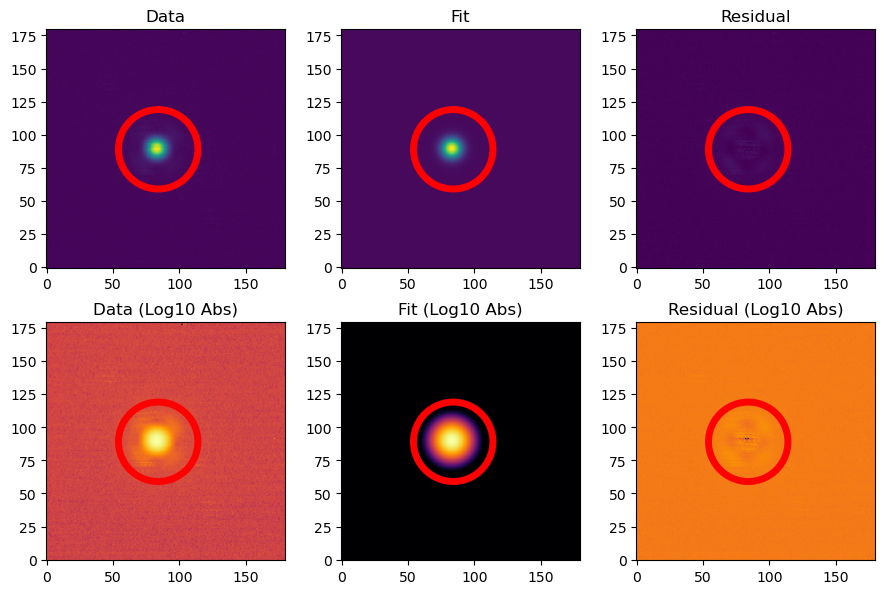

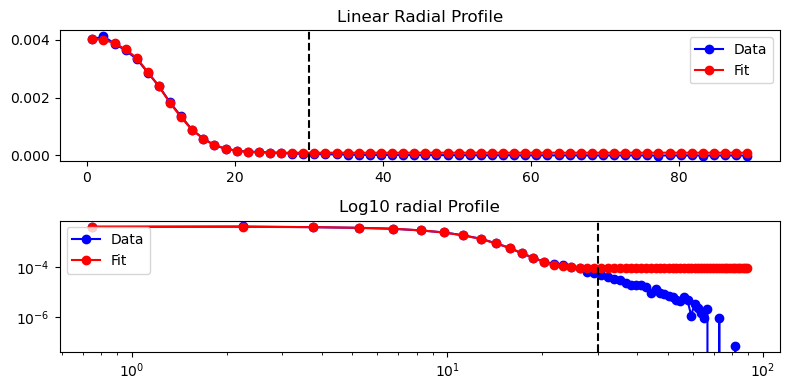

In [3]:
map2use = maps_f090[0]
T = map2use.solved[0]
W = map2use.weights[0][0]
muy, mux= np.unravel_index(np.argmax(T), (180,180))
ny,nx = T.shape
y, x = np.mgrid[0:ny, 0:nx]
coords = (y, x)

radius = 30
dist = np.sqrt((x - mux)**2 + (y - muy)**2)
mask = dist <= radius

model = mf.EllipticGaussian()
popt, perr, pcov, infodict, mesg, ier = model.fit(mapdata=T, weights=W, mask=mask)
if ier not in [1,2,3,4]:
    raise Exception(f"Fit did not work! (ier = {ier})")
fit = model.func((y, x), *popt).reshape((180,180))
residual = T - fit
chi2, chi2red = model.chi2((ny,nx), infodict)

print(chi2red)
pf.plot_fit_result(T, fit, residual=residual, circle_radius=radius, circle_center=(mux,muy))

4.153421003224068


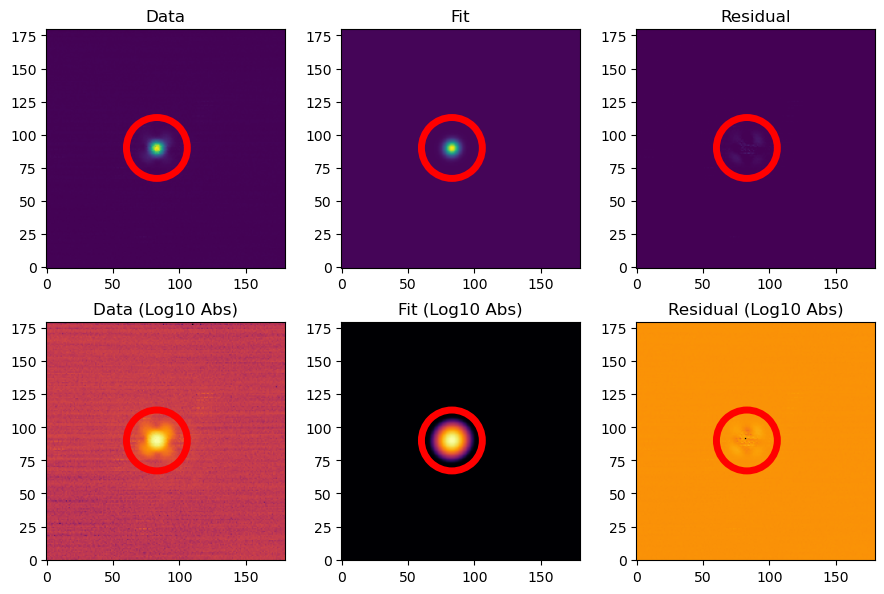

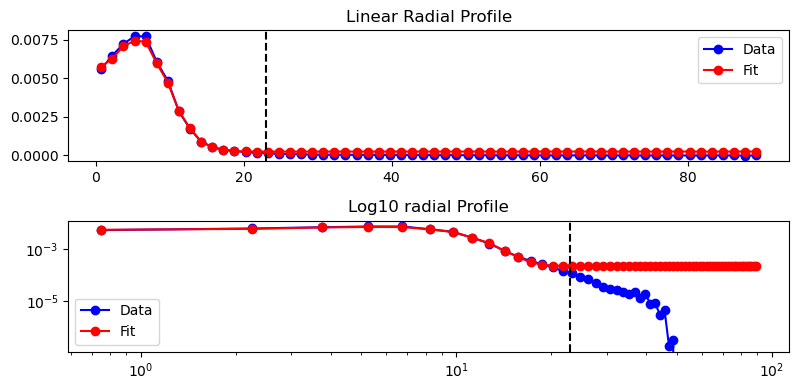

In [4]:
map2use = maps_f150[0]
T = map2use.solved[0]
W = map2use.weights[0][0]
mux, muy= np.unravel_index(np.argmax(T), (180,180))
ny,nx = T.shape
y, x = np.mgrid[0:ny, 0:nx]
coords = (y, x)

radius = 23
dist = np.sqrt((x - mux)**2 + (y - muy)**2)
mask = dist <= radius

model = mf.EllipticGaussian()
popt, perr, pcov, infodict, mesg, ier = model.fit(mapdata=T, weights=W, mask=mask)
if ier not in [1,2,3,4]:
    raise Exception(f"Fit did not work! (ier = {ier})")
fit = model.func((y, x), *popt).reshape((180,180))
residual = T - fit
chi2, chi2red = model.chi2((ny,nx), infodict)

print(chi2red)
pf.plot_fit_result(T, fit, residual=residual, circle_radius=radius, circle_center=(muy,mux))

## Fit Models to Maps

#### Load Maps 📥

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import map_fun as mf
from tqdm.notebook import tqdm
import inspect, msgspec

mf.maps_maps_path = "/global/u2/a/andrs/Products/Mars/i1/"
mf.maps_dict = "/global/u2/a/andrs/Products/Mars/i1/maps.json"

with open(mf.maps_dict, "rb") as f:
    encoded = f.read()

maps_meta = msgspec.json.decode(encoded)

maps = mf.load_maps(wafer='*', band='*')

print(f"Loaded a total of {len(maps)} maps. (Not counting scan splits)")

Loaded a total of 310 maps. (Not counting scan splits)


**NOTES REGARDING FITTING STAGE** 
- If the full data fit fails, then we automatically skip the direction scans as well.
- We will be fitting models to the residuals later on. We avoid a model that tries to fit residuals as well until we can study the behaviour of residuals by themselves later on.

#### 2D Elliptical Gauss Model

**FILL THIS PART WITH APPROPRIATE FORMULA LATER**

In [6]:
no_good = 0
kinds = {0: 'full', 1: 'lscans', 2: 'rscans'}

for i, map_ in enumerate(tqdm(maps, desc="Fitting maps w/ elliptical model")):    
    for cati, cat in enumerate(range(3)):
        kind = kinds[cat]
        # I do this loop like this in order to avoid creating copies
        if cat == 0:
            map2use = map_
        elif cat == 1:
            map2use = map_.lscans
        elif cat == 2:
            map2use = map_.rscans

        T = map2use.solved[0]
        W = map2use.weights[0][0]
        mux, muy= np.unravel_index(np.argmax(T), (180,180))
        ny,nx = T.shape
        y, x = np.mgrid[0:ny, 0:nx]
        coords = (y, x)

        if map2use.band == 'f090':
            radius = 30
        elif map2use.band == 'f150':
            radius = 25
            
        dist = np.sqrt((x - mux)**2 + (y - muy)**2)
        mask = dist <= radius

        model = mf.EllipticGaussian()
        model_name = model.name
        maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"][kind]["fits"][model_name] = {}
        if cati == 0:
            maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"]["lscans"]["fits"][model_name] = {}
            maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"]["rscans"]["fits"][model_name] = {}
        try:
            popt, perr, pcov, infodict, mesg, ier = model.fit(mapdata=T, weights=W, mask=mask)
        except Exception as e:
            maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"][kind]["fits"][model_name]["fit_mesg"] = str(e)
            maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"][kind]["fits"][model_name]["valid"] = False
            print(e)

            if cat == 0:
                no_good +=3
                maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"]["lscans"]["fits"][model_name]["fit_mesg"] = "Full data fit failed. Check entry for logged reason."
                maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"]["rscans"]["fits"][model_name]["fit_mesg"] = "Full data fit failed. Check entry for logged reason."
                maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"]["lscans"]["fits"][model_name]["valid"] = False
                maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"]["rscans"]["fits"][model_name]["valid"] = False
                break
            else:
                no_good +=1
                continue
        
        if int(ier) not in [1,2,3,4]:
            maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"][kind]["fits"][model_name]["fit_mesg"] = str(mesg)
            maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"][kind]["fits"][model_name]["valid"] = False
            if cat == 0:
                no_good +=3
                maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"]["lscans"]["fits"][model_name]["fit_mesg"] = "Full data fit failed. Check entry for logged reason."
                maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"]["rscans"]["fits"][model_name]["fit_mesg"] = "Full data fit failed. Check entry for logged reason."
                maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"]["lscans"]["fits"][model_name]["valid"] = False
                maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"]["rscans"]["fits"][model_name]["valid"] = False
                break
            else:
                no_good +=1 
                continue

        else:
            params = list(inspect.signature(model.func).parameters.keys())[1:]
            profile = model.profile(popt, pcov)
            checkfinite = lambda x: 0 if not np.isfinite(x) else x
            dikt = {}
            for i, param in enumerate(params):
                dikt.update({param: (float(popt[i]), float(perr[i]))})
            maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"][kind]["fits"][model_name][f"params"] = dikt

            
            maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"][kind]["fits"][model_name]["profile"] = profile

            maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"][kind]["fits"][model_name]["valid"] = True
            maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"][kind]["fits"][model_name]["fit_mesg"] = str(mesg)
            chi2, chi2_red  = model.chi2(T.shape, infodict)
            maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"][kind]["fits"][model_name]["chi2"] = float(chi2)
            maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"][kind]["fits"][model_name]["chi2_red"] = float(chi2_red)
    
print(f"{len(maps)*3 - no_good} maps have been fitted out of {len(maps)*3} total maps. (Includes scan splits.)")

Fitting maps w/ elliptical model:   0%|          | 0/310 [00:00<?, ?it/s]

930 maps have been fitted out of 930 total maps. (Includes scan splits.)


In [7]:
encoded = msgspec.json.encode(maps_meta)

with open(mf.maps_dict, "wb") as f:
    f.write(encoded)

#### Get SNR 🎯

Here we attempt to get the estimated SNR of each map. This step will be useful when we determine what maps we actually want to load. In the case we get invalid values or some error, then we will keep the snr as zero.

80.60211365542654


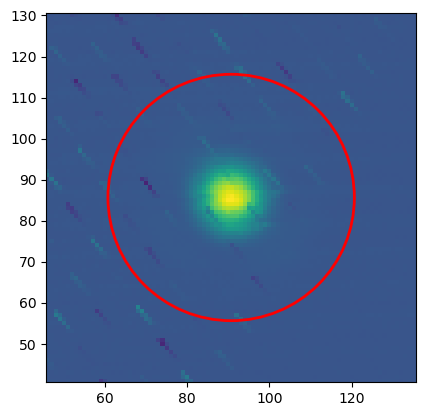

In [8]:
# TEST FOR SINGLE CASE
# WITHIN CIRCLE MEANS DON'T CONSIDER NOISE

map2use = maps[0]
T = map2use.solved[0]
W = map2use.weights[0][0]
ny, nx = T.shape
y, x = np.mgrid[0:ny, 0:nx]
coords = (y, x)

mux = maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"]["full"]["fits"]["EllipticGaussian"]["params"]["mux"][0]
muy = maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"]["full"]["fits"]["EllipticGaussian"]["params"]["muy"][0]
sigx = maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"]["full"]["fits"]["EllipticGaussian"]["params"]["sigx"][0]
sigy = maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"]["full"]["fits"]["EllipticGaussian"]["params"]["sigy"][0]
A = maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"]["full"]["fits"]["EllipticGaussian"]["params"]["amp"][0]


radius = 30 if map2use.band=='f090' else 25

# Compute distance from center
dist = np.sqrt((x - mux)**2 + (y - muy)**2)

# Mask pixels inside the circle
inside_circle = dist <= radius
outside_circle = ~inside_circle

# Estimate noise outside the circle
noise_std = np.std(T[outside_circle])

# Compute SNR
snr = A / noise_std


fig, ax = plt.subplots()

# Parameters for the circle
center = (mux, muy)    # (x, y)

# Create a circle patch
circle = plt.Circle(center, radius, color='r', fill=False, linewidth=2)

# Plot your 2D data (e.g., residual)
ax.imshow(T, origin='lower', cmap='viridis')

# Add the circle to the axes
ax.add_patch(circle)

# Optionally, set limits to focus on the area
ax.set_xlim(center[0] - radius*1.5, center[0] + radius*1.5)
ax.set_ylim(center[1] - radius*1.5, center[1] + radius*1.5)
print(snr)
plt.show()

In [9]:
def fit_snr(mapdata):
    map2use = mapdata
    T = map2use.solved[0]
    W = map2use.weights[0][0]
    ny, nx = T.shape
    y, x = np.mgrid[0:ny, 0:nx]
    coords = (y, x)
    
    mux = maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"]["full"]["fits"]["EllipticGaussian"]["params"]["mux"][0]
    muy = maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"]["full"]["fits"]["EllipticGaussian"]["params"]["muy"][0]
    sigx = maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"]["full"]["fits"]["EllipticGaussian"]["params"]["sigx"][0]
    sigy = maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"]["full"]["fits"]["EllipticGaussian"]["params"]["sigy"][0]
    A = maps_meta[map2use.obs_id][f"{map2use.band}-{map2use.wafer}"]["full"]["fits"]["EllipticGaussian"]["params"]["amp"][0]
    
    
    radius = 30 if map2use.band == 'f090' else 25
    
    # Compute distance from center
    dist = np.sqrt((x - mux)**2 + (y - muy)**2)
    
    # Mask pixels inside the circle
    inside_circle = dist <= radius
    outside_circle = ~inside_circle
    
    # Estimate noise outside the circle
    noise_std = np.nanstd(T[outside_circle])
    
    # Compute SNR
    snr = A / noise_std
    #print(snr)
    return snr


for map_ in maps:
    map2fit = map_
    try:
        snr = fit_snr(map2fit)
        snr = 0 if not np.isfinite(snr) else snr
    except Exception as e:
        print(e)
        snr = float(0)
        
    obs_id, wafer, band = str(map2fit.obs_id), str(map2fit.wafer), str(map2fit.band)
    maps_meta[obs_id][f"{band}-{wafer}"]["full"]["snr"] = float(snr)

    map2fit = map_.lscans
    try:
        snr = fit_snr(map2fit)
        snr = 0 if not np.isfinite(snr) else snr
    except Exception as e:
        print(e)
        snr = float(0)
        
    obs_id, wafer, band = str(map2fit.obs_id), str(map2fit.wafer), str(map2fit.band)
    maps_meta[obs_id][f"{band}-{wafer}"]["lscans"]["snr"] = float(snr)

    map2fit = map_.rscans
    try:
        snr = fit_snr(map2fit)
        snr = 0 if not np.isfinite(snr) else snr
    except Exception as e:
        print(e)
        snr = float(0)
        
    obs_id, wafer, band = str(map2fit.obs_id), str(map2fit.wafer), str(map2fit.band)
    maps_meta[obs_id][f"{band}-{wafer}"]["rscans"]["snr"] = float(snr)

for map_ in maps:
    map2fit = map_
    try:
        snr = fit_snr(map2fit)
        snr = 0 if not np.isfinite(snr) else snr
    except Exception as e:
        print(e)
        snr = float(0)
        
    obs_id, wafer, band = str(map2fit.obs_id), str(map2fit.wafer), str(map2fit.band)
    maps_meta[obs_id][f"{band}-{wafer}"]["full"]["snr"] = float(snr)

    map2fit = map_.lscans
    try:
        snr = fit_snr(map2fit)
        snr = 0 if not np.isfinite(snr) else snr
    except Exception as e:
        print(e)
        snr = float(0)
        
    obs_id, wafer, band = str(map2fit.obs_id), str(map2fit.wafer), str(map2fit.band)
    maps_meta[obs_id][f"{band}-{wafer}"]["lscans"]["snr"] = float(snr)

    map2fit = map_.rscans
    try:
        snr = fit_snr(map2fit)
        snr = 0 if not np.isfinite(snr) else snr
    except Exception as e:
        print(e)
        snr = float(0)
        
    obs_id, wafer, band = str(map2fit.obs_id), str(map2fit.wafer), str(map2fit.band)
    maps_meta[obs_id][f"{band}-{wafer}"]["rscans"]["snr"] = float(snr)

In [10]:
encoded = msgspec.json.encode(maps_meta)

with open(mf.maps_dict, "wb") as f:
    f.write(encoded)